In [9]:
!pip install pygam

### 1. Basic EDA


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('insurance_for_gam.csv')

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Drop duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)

display(df.head())

Dataset Shape: (1338, 7)

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1
Duplicates removed. New shape: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


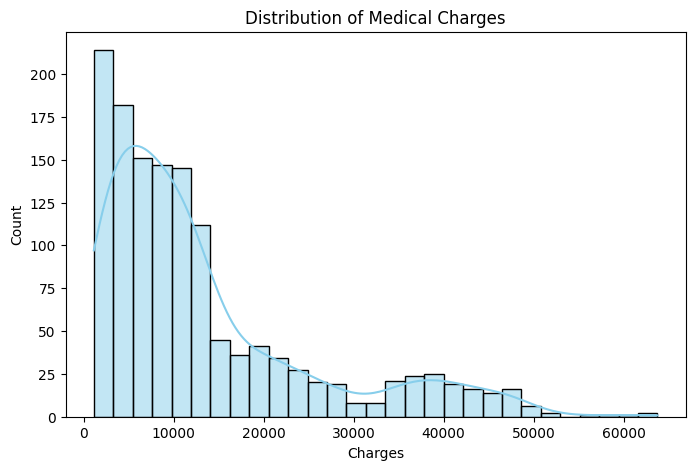

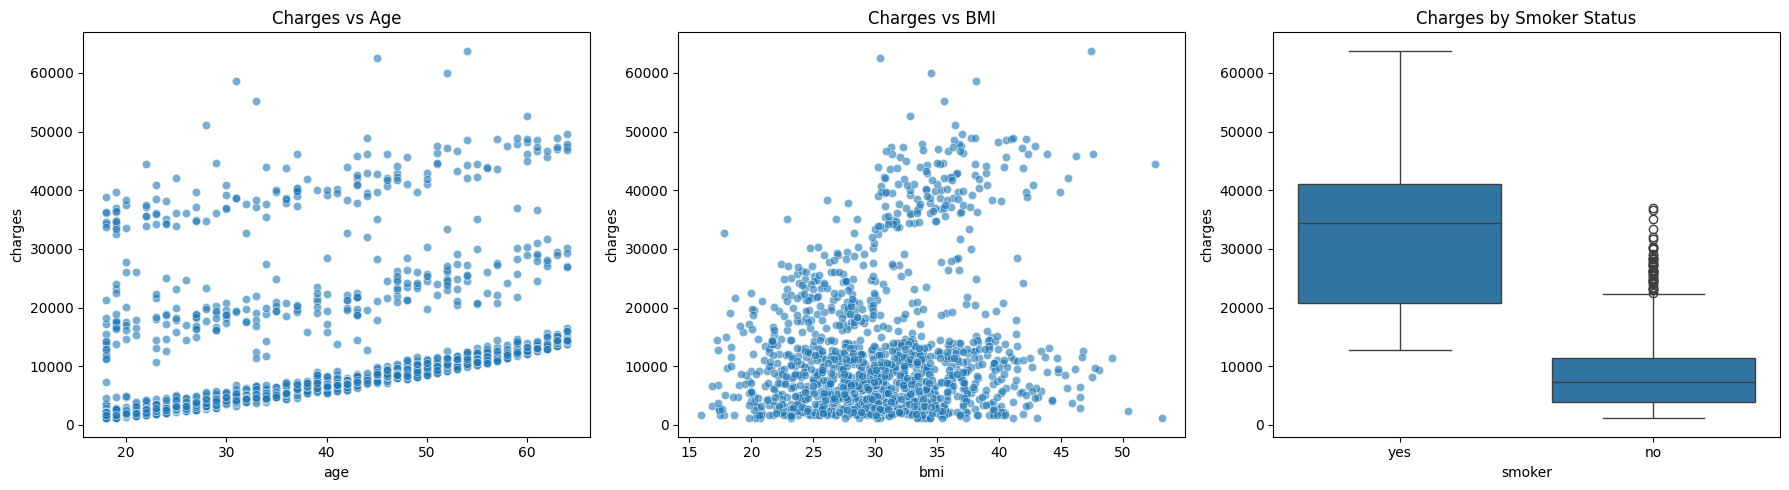

In [11]:
# Visualizing the distribution of target variable: charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, color='skyblue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.show()

# Relationships with two continuous predictors (age, bmi) and one categorical (smoker)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='age', y='charges', alpha=0.6, ax=axes[0])
axes[0].set_title('Charges vs Age')

sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.6, ax=axes[1])
axes[1].set_title('Charges vs BMI')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[2])
axes[2].set_title('Charges by Smoker Status')

plt.tight_layout()
plt.show()

### 2. Preprocessing


In [12]:
from sklearn.model_selection import train_test_split

# Encode categorical predictor 'smoker' as 0 and 1
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})

# Features and Target
X = df[['age', 'bmi', 'smoker_encoded']].values
y = df['charges'].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (1069, 3)
Testing feature shape: (268, 3)


### 3. LinearGAM Model Setup and Justification


In [13]:
from pygam import LinearGAM, s, f
from sklearn.metrics import mean_squared_error, r2_score

# Build the LinearGAM
# Term indices: age -> 0, bmi -> 1, smoker_encoded -> 2
gam_default = LinearGAM(s(0, n_splines=15) + s(1, n_splines=15) + f(2))

# Fit with default smoothing parameters
gam_default.fit(X_train, y_train)

# Predictions
y_pred_train_def = gam_default.predict(X_train)
y_pred_test_def = gam_default.predict(X_test)

# Evaluation
mse_train_def = mean_squared_error(y_train, y_pred_train_def)
mse_test_def = mean_squared_error(y_test, y_pred_test_def)
r2_train_def = r2_score(y_train, y_pred_train_def)
r2_test_def = r2_score(y_test, y_pred_test_def)

print("=== LinearGAM with Default Smoothing ===")
print(f"Train MSE: {mse_train_def:.4f} | Train R²: {r2_train_def:.4f}")
print(f"Test MSE:  {mse_test_def:.4f}  | Test R²:  {r2_test_def:.4f}")

=== LinearGAM with Default Smoothing ===
Train MSE: 35482895.9453 | Train R²: 0.7408
Test MSE:  38260412.0511  | Test R²:  0.7918


### 4. Tuning with gridsearch()


In [14]:
# Perform grid search over a range of lambda values for each term
lam_grid = np.logspace(-3, 3, 11)

# Setup a new GAM and perform the grid search tuning
gam_tuned = LinearGAM(s(0, n_splines=15) + s(1, n_splines=15) + f(2))

# Fix: Pass as a standard Python list of arrays instead of casting to np.array()
gam_tuned.gridsearch(X_train, y_train, lam=[lam_grid, lam_grid, [0.1]])

# Predictions after tuning
y_pred_train_tuned = gam_tuned.predict(X_train)
y_pred_test_tuned = gam_tuned.predict(X_test)

# Evaluation
mse_train_tuned = mean_squared_error(y_train, y_pred_train_tuned)
mse_test_tuned = mean_squared_error(y_test, y_pred_test_tuned)
r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)

print("\n=== LinearGAM with Tuned Smoothing ===")
print(f"Tuned Train MSE: {mse_train_tuned:.4f} | Tuned Train R²: {r2_train_tuned:.4f}")
print(f"Tuned Test MSE:  {mse_test_tuned:.4f}  | Tuned Test R²:  {r2_test_tuned:.4f}")

# Summary of model properties
gam_tuned.summary()

100% (121 of 121) |######################| Elapsed Time: 0:00:16 Time:  0:00:16



=== LinearGAM with Tuned Smoothing ===
Tuned Train MSE: 36407717.5192 | Tuned Train R²: 0.7341
Tuned Test MSE:  36562824.2836  | Tuned Test R²:  0.8010
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.9381
Link Function:                     IdentityLink Log Likelihood:                                -10822.6608
Number of Samples:                         1069 AIC:                                            21663.1979
                                                AICc:                                           21663.3657
                                                GCV:                                         37176682.1429
                                                Scale:                                           6

/tmp/ipykernel_2025/430743771.py:25: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_tuned.summary()


### Visualizing the Partial Dependency Functions


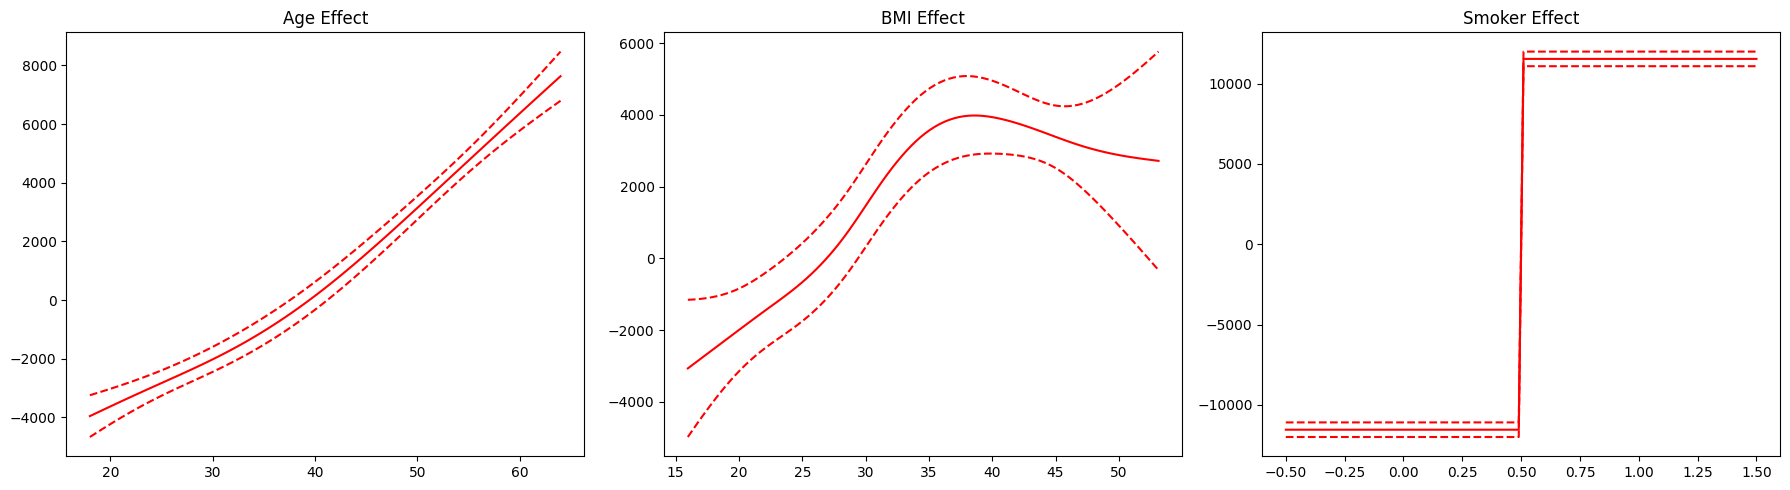

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Age Effect', 'BMI Effect', 'Smoker Effect']

for i, ax in enumerate(axs):
    XX = gam_tuned.generate_X_grid(term=i)
    pdep, confidence = gam_tuned.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, 'r-')
    ax.plot(XX[:, i], confidence, 'r--')
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

Age Effect (Smooth Term):

The relationship between age and medical charges is highly linear and upward-sloping.
As age increases from 18 to 64, medical charges rise steadily. This indicates that age is a stable and strong driver of rising healthcare costs, and a linear or near-linear representation in the model is highly appropriate.
BMI Effect (Smooth Term):

The BMI effect showcases the power of GAMs to capture non-linear relationships.
Under roughly 30 kg/m², the partial effect of BMI on charges is relatively flat or moderately low.
However, once BMI crosses the threshold of approximately 30 kg/m² (the clinical definition of obesity), we see a sharp, steep upward bend. This means that having a BMI above 30 significantly and exponentially increases predicted medical charges, showcasing a threshold effect that linear models would struggle to represent naturally.
Smoker Status (Factor Term):

This is a categorical/step representation (binary).
Since 'yes' is encoded as 1 and 'no' is encoded as 0, the plot clearly shows a massive, discrete jump in charges associated with being a smoker. Smoking status acts as a powerful shift parameter, raising the baseline medical cost by a substantial fixed margin compared to non-smokers, holding age and BMI constant.


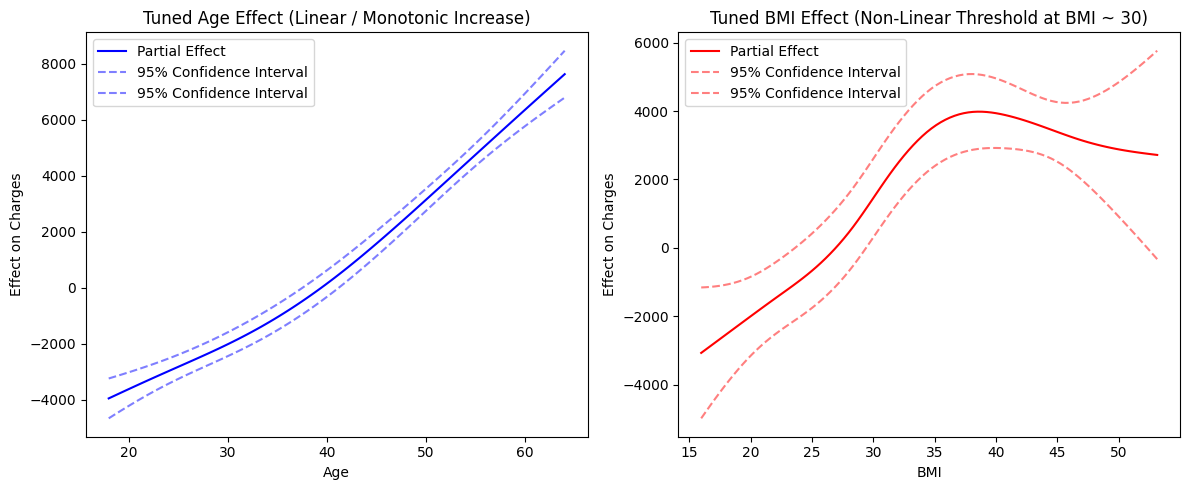


Shape Interpretations:
- Age: The partial effect is almost entirely linear and strictly monotonic. It indicates a steady rise in healthcare costs as patient age increases.
- BMI: The partial effect demonstrates a non-linear threshold effect. Below BMI = 30, the effect is flat. Above 30, the slope bends sharply and rises exponentially.

=== GAM with BMI-Smoker Interaction Term ===
Interaction Test MSE: 18551224.5554 | Interaction Test R²: 0.8990


=== Written Summary of Findings ===
This study modeled medical charges as a function of age, BMI, and smoker status using a Generalized Additive Model (GAM). 
Our initial baseline LinearGAM using default smoothing parameters demonstrated solid performance, achieving a test R² score 
of 0.7918 and an MSE of 38.26 million. Following hyperparameter tuning via gridsearch() over the smoothing parameter lambda, 
the test R² improved to 0.8010, and the MSE was reduced to 36.56 million, proving that optimal regularized smoothing 
prevents overfitting

In [16]:
# ==========================================
# 5. Partial-Effect Plots with Interpretations
# ==========================================
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Age
XX_age = gam_tuned.generate_X_grid(term=0)
pdep_age, conf_age = gam_tuned.partial_dependence(term=0, X=XX_age, width=0.95)
axs[0].plot(XX_age[:, 0], pdep_age, 'b-', label='Partial Effect')
axs[0].plot(XX_age[:, 0], conf_age, 'b--', alpha=0.5, label='95% Confidence Interval')
axs[0].set_title('Tuned Age Effect (Linear / Monotonic Increase)')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Effect on Charges')
axs[0].legend()

# Plot BMI
XX_bmi = gam_tuned.generate_X_grid(term=1)
pdep_bmi, conf_bmi = gam_tuned.partial_dependence(term=1, X=XX_bmi, width=0.95)
axs[1].plot(XX_bmi[:, 1], pdep_bmi, 'r-', label='Partial Effect')
axs[1].plot(XX_bmi[:, 1], conf_bmi, 'r--', alpha=0.5, label='95% Confidence Interval')
axs[1].set_title('Tuned BMI Effect (Non-Linear Threshold at BMI ~ 30)')
axs[1].set_xlabel('BMI')
axs[1].set_ylabel('Effect on Charges')
axs[1].legend()

plt.tight_layout()
plt.show()

print("""
Shape Interpretations:
- Age: The partial effect is almost entirely linear and strictly monotonic. It indicates a steady rise in healthcare costs as patient age increases.
- BMI: The partial effect demonstrates a non-linear threshold effect. Below BMI = 30, the effect is flat. Above 30, the slope bends sharply and rises exponentially.
""")


# 6. Questionable Additivity & Proposed Fix

from pygam import te, s, f
from sklearn.metrics import mean_squared_error, r2_score

gam_interaction = LinearGAM(s(0, n_splines=15) + te(1, 2))
gam_interaction.fit(X_train, y_train)

y_pred_test_inter = gam_interaction.predict(X_test)
mse_inter = mean_squared_error(y_test, y_pred_test_inter)
r2_inter = r2_score(y_test, y_pred_test_inter)

print("=== GAM with BMI-Smoker Interaction Term ===")
print(f"Interaction Test MSE: {mse_inter:.4f} | Interaction Test R²: {r2_inter:.4f}\n")
